# Offerpad-style pricing walkthrough
Valuation → causal price effects → margin optimization, on simulated data with known ground truth.
Run top to bottom (~1 min). Change `SimConfig` parameters to stress-test conclusions.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '..')
from offerpad_simulator.config import SimConfig
from offerpad_simulator.simulate import simulate, simulate_history, true_accept_prob, observed_columns
from offerpad_simulator.valuation import evaluate
from offerpad_simulator import causal, optimize, seller_psych
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
cfg = SimConfig(n_leads=40_000, seed=7)
df, ovm, hist = simulate(cfg, return_ovm=True)
df[observed_columns(df)].head()

,lead_id,market,beds,sqft,baths,age,lot_acres,school_score,month,day,v_hat,v_lo,v_hi,unc_halfwidth,v_hedonic,...,past_hpa_12m,accept,v_hat_resale,list_exp_offset,list_exp_arm,in_list_experiment,list_ratio,list_price,dom,sold_60d,sale_price,holding_cost,gross_profit,contribution,seller_stated_value
0,0,1,3,1956.0,3.0,19.2,0.139,7.3,6,529,286973.047648,265318.014385,312646.959716,0.082073,288992.201170,...,0.03,0,287554.752620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,312170.389193
1,1,0,3,1747.0,3.0,13.8,0.206,3.9,3,443,218610.610542,203518.246840,235757.037205,0.073523,213277.249407,...,0.01,1,218611.431017,0.0,0.0,1.0,1.031138,225418.528778,16.0,1.0,222713.506432,2212.339379,26736.806560,18956.629520,NaN
2,2,3,3,2222.0,3.0,19.7,0.299,10.0,1,384,462152.756160,416569.045273,490604.333816,0.081793,443102.451400,...,0.07,1,463717.062189,0.0,0.0,0.0,1.001281,464311.146513,34.0,1.0,457822.850797,6507.110807,51531.569649,33578.887572,NaN
3,3,4,4,1885.0,3.0,12.1,0.104,4.8,4,95,355759.134411,333252.087159,378159.496759,0.063208,359363.487319,...,0.02,0,356074.307407,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,370310.275088
4,4,5,5,2553.0,4.0,33.4,0.142,5.2,5,138,500628.727234,459874.296028,524745.614803,0.065980,500261.637746,...,0.09,1,502446.727896,0.0,0.0,0.0,0.966345,485536.734864,156.0,0.0,427007.590418,20485.727518,-10044.263633,-41205.180912,501394.789998


## 1. Valuation model

In [2]:
test = simulate_history(SimConfig(n_history=8000), np.random.default_rng(1))
evaluate(ovm, test)

{'hedonic_median_ape': 0.04270044329925435,
 'gbm_median_ape': 0.04112101984943829,
 'gbm_within_5pct': 0.58725,
 'interval80_coverage': 0.75125,
 'abs_err_by_uncertainty_quintile': [0.0368, 0.0375, 0.038, 0.0427, 0.0536]}

## 2. Confounding: observational vs randomized price variation

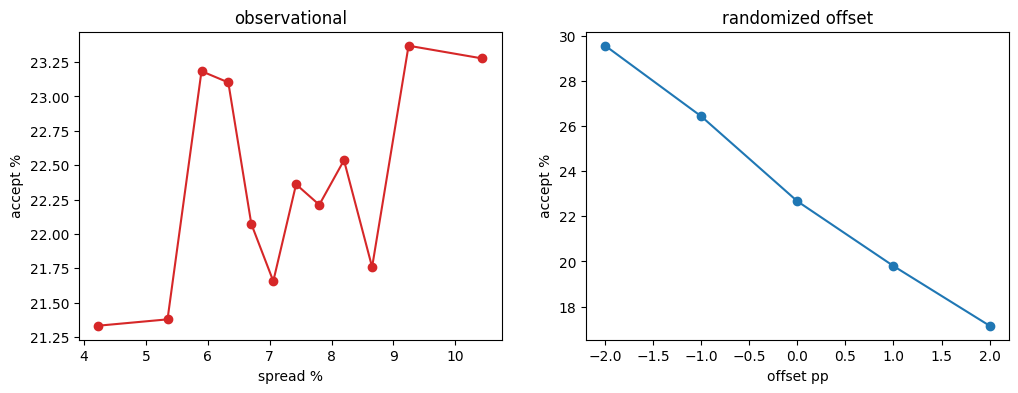

In [3]:
obs = df[df.in_experiment == 0]
exp_ = df[df.in_experiment == 1]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
g = obs.groupby(pd.qcut(obs.spread, 12), observed=True).agg(s=('spread', 'mean'), a=('accept', 'mean'))
ax[0].plot(g.s * 100, g.a * 100, 'o-', c='C3'); ax[0].set(title='observational', xlabel='spread %', ylabel='accept %')
e = exp_.groupby('exp_offset').accept.mean()
ax[1].plot(e.index * 100, e * 100, 'o-'); ax[1].set(title='randomized offset', xlabel='offset pp', ylabel='accept %')
plt.show()

## 3. Estimators vs truth (effect of +1pp spread on acceptance, pp)

In [4]:
est = causal.seller_side_estimates(df, n_boot=5)
est[['estimator', 'estimate', 'se', 'truth', 'note']].round(2)

,estimator,estimate,se,truth,note
0,Naive OLS (LPM),-0.35,0.13,-2.98,controls for X only
1,Naive logit (AME),-0.34,0.13,-2.98,controls for X only
2,DML (X only),-0.83,0.14,-2.98,"flexible in X, but U is still omitted"
3,2SLS: randomized spread arm,-2.92,0.24,-2.98,"first-stage F = 20,128"
4,2SLS: analyst leniency (LOO),-3.41,0.33,-2.98,"first-stage F = 7,770"
5,2SLS: algorithm v2 cutover,-2.33,1.61,-2.98,first-stage F = 262
6,2SLS: mortgage-rate shifter (INVALID),5.82,3.51,-2.98,first-stage F = 64
7,2SLS: all valid IVs,-3.07,0.19,-2.98,Wooldridge over-id p = 0.445
8,2SLS: valid + rate (J-test),-3.04,0.19,-2.98,Wooldridge over-id p = 0.034
9,Control-function logit (2SRI) AME,-2.89,0.08,-2.98,residual coef = 0.365 (endogeneity test)


In [5]:
causal.buyer_side_estimates(df, cfg)[['estimator', 'estimate', 'se', 'truth']].round(3)

,estimator,estimate,se,truth
0,Naive OLS: sold<=60d,0.333,0.198,-4.583
1,2SLS: randomized list-price arm,-4.558,0.389,-4.583
2,Naive OLS: log DOM (theta/100),-0.008,0.005,0.120
3,2SLS: log DOM (theta/100),0.110,0.009,0.120


## 4. Worked example: 3% price changes

In [6]:
print('Seller side, offer +3%:', f"{df.true_p_accept.mean():.1%} -> {true_accept_prob(df, price_mult=1.03).mean():.1%}")
b = optimize.buyer_policy_curves(df, cfg=cfg)
optimize.three_percent_cut_table(b['curves']).round(2).T

Seller side, offer +3%: 22.8% -> 31.7%


planner,causal (2SLS),naive (OLS),truth
P(sold<=60d) now,0.65,0.67,0.71
P(sold<=60d) at -3%,0.77,0.66,0.83
Δ P60 (pp),11.43,-0.91,12.11
E[DOM] now,60.89,55.79,53.04
E[DOM] at -3%,43.56,57.13,36.80
Δ revenue ($),-4203.00,-8315.49,-4644.19
Δ holding cost ($),-1228.93,95.43,-1155.07
Δ contribution ($/home),-2869.00,-8203.04,-3373.02


## 5. Optimization: seller spread and buyer list price

,planner,delta_star_pp,believed_contribution,true_contribution,true_accept_rate,regret_vs_truth_opt
0,truth,3.00,3062.05,3062.05,0.15,0.00
1,causal (CF logit + winner's curse),2.75,2937.93,3060.07,0.15,1.99
2,"causal acceptance, ignores winner's curse",3.25,3153.01,3059.33,0.14,2.72
3,naive (confounded logit),6.00,6433.99,2800.33,0.09,261.72


,planner,rho_star,believed_contribution,true_contribution,true_p_sold_60d,regret_vs_truth_opt
0,truth,1.025,12303.226,12303.226,0.597,0.000
1,causal (2SLS),1.020,11319.746,12277.579,0.621,25.648
2,naive (OLS),1.080,32888.317,9104.012,0.352,3199.215


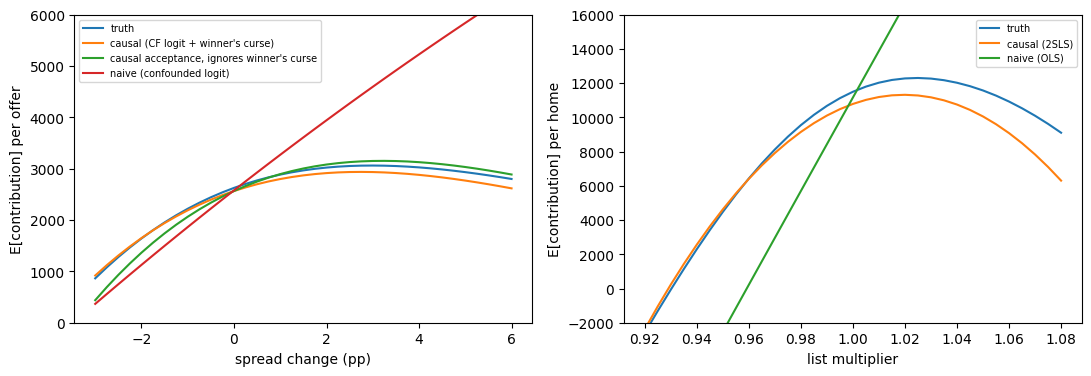

In [7]:
s = optimize.seller_policy_curves(df, cfg=cfg)
display(s['optimum'].round(2)); display(b['optimum'].round(3))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for n, g in s['curves'].groupby('planner', sort=False): ax[0].plot(g.delta_pp, g.contribution_per_lead, label=n)
for n, g in b['curves'].groupby('planner', sort=False): ax[1].plot(g.rho, g.contribution, label=n)
ax[0].set(xlabel='spread change (pp)', ylabel='E[contribution] per offer', ylim=(0, 6000)); ax[0].legend(fontsize=7)
ax[1].set(xlabel='list multiplier', ylabel='E[contribution] per home', ylim=(-2000, 16000)); ax[1].legend(fontsize=7)
plt.show()

## 6. Customer self-appreciation

In [8]:
sa = seller_psych.self_appreciation_summary(df)
print(f"stated premium = {sa['base_premium']:.3f} + {sa['passthrough']:.2f} x trailing HPA")
display(sa['by_market'].round(3)); display(sa['adverse_selection'].round(4))

stated premium = 0.029 + 0.63 x trailing HPA


,market,past_hpa_12m,stated_premium,true_self_apprec,accept_rate
0,0,0.01,0.035,0.037,0.274
1,1,0.03,0.048,0.048,0.238
2,2,0.05,0.060,0.060,0.199
3,3,0.07,0.074,0.072,0.203
4,4,0.02,0.042,0.041,0.278
5,5,0.09,0.085,0.084,0.167


,mean,std,size
accept,,,
rejected offer,0.0081,0.0589,30945
accepted offer,-0.0271,0.0583,9055


## 7. Try it: what if analysts had no soft information?
Set `analyst_soft_info=0` — the naive estimate should move close to the truth, because the confounding path disappears.

In [9]:
df2 = simulate(SimConfig(n_leads=30_000, analyst_soft_info=0.0, seed=7))
causal.seller_side_estimates(df2, n_boot=2)[['estimator', 'estimate', 'truth']].round(2).head(4)

,estimator,estimate,truth
0,Naive OLS (LPM),-3.07,-2.99
1,Naive logit (AME),-3.08,-2.99
2,DML (X only),-3.15,-2.99
3,2SLS: randomized spread arm,-3.21,-2.99
